In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("outputs/df_sp500_filtrado_symbols.csv")

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92194 entries, 0 to 92193
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           92194 non-null  object
 1   Url            92194 non-null  object
 2   Article        92194 non-null  object
 3   Stock_symbol   92194 non-null  object
 4   Article_title  92194 non-null  object
dtypes: object(5)
memory usage: 3.5+ MB


In [11]:
df.Stock_symbol[1]

'DNOV'

In [12]:
df.Url[1]

'https://www.nasdaq.com/articles/tuesday-sector-laggards%3A-materials-consumer-products'

In [13]:
print(df.Article[1])

Looking at the sectors faring worst as of midday Tuesday, shares of Materials companies are underperforming other sectors, higher by 0.2%. Within the sector, FMC Corp. (Symbol: FMC) and Newmont Corp (Symbol: NEM) are two large stocks that are lagging, showing a loss of 9.3% and 3.7%, respectively. Among the high volume ETFs, one ETF closely following materials stocks is the Materials Select Sector SPDR ETF (Symbol: XLB), which is up 0.6% on the day, and down 0.44% year-to-date. FMC Corp., meanwhile, is down 56.50% year-to-date, and Newmont Corp, is down 22.41% year-to-date. Combined, FMC and NEM make up approximately 4.4% of the underlying holdings of XLB.
The next worst performing sector is the Consumer Products sector, up 0.3%. Among large Consumer Products stocks, VF Corp. (Symbol: VFC) and Royal Caribbean Group (Symbol: RCL) are the most notable, showing a loss of 13.6% and 1.6%, respectively. One ETF closely tracking Consumer Products stocks is the iShares U.S. Consumer Goods ETF 

# Test 1 para determinar el tópico del artículo

In [ ]:
#!pip install -q sentence-transformers umap-learn scikit-learn pandas numpy tqdm

In [15]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
import umap

In [16]:
df["clean_text"] = df["Article"].str.replace(r'\s+', ' ', regex=True).str.strip()

In [17]:
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Generando embeddings de texto...")
embeddings = model.encode(df["clean_text"].tolist(), show_progress_bar=True, batch_size=64)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\Ceci\Documents\github\deep_learning\env\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Ceci\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generando embeddings de texto...


Batches:   0%|          | 0/1441 [00:00<?, ?it/s]

# Umap + KMeans con dimensionalidad "Alta" (20 dimensiones)

In [ ]:
print("Reduciendo dimensionalidad con UMAP...") ### ¿debería haber escalao los datos antes?
umap_model = umap.UMAP(n_neighbors=15, n_components=20, random_state=42) #creo que dos componentes sería mejor así grafico
embeddings_reduced = umap_model.fit_transform(embeddings)

Reduciendo dimensionalidad con UMAP...


c:\Users\Ceci\Documents\github\deep_learning\env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [19]:
num_clusters = 20  # testear con diferentes números de clusters
print(f"Aplicando KMeans con {num_clusters} clusters...")
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(embeddings_reduced)

Aplicando KMeans con 20 clusters...


In [20]:
print("Extrayendo palabras clave por cluster...")
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X_tfidf = vectorizer.fit_transform(df["clean_text"])
feature_names = np.array(vectorizer.get_feature_names_out())

topn = 10  # cantidad de palabras clave por cluster
keywords = {}

for i in range(num_clusters):
    # promediar TF-IDF dentro del cluster
    cluster_indices = np.where(df["cluster"] == i)[0]
    if len(cluster_indices) == 0:
        continue
    cluster_tfidf = X_tfidf[cluster_indices].mean(axis=0)
    top_indices = np.argsort(cluster_tfidf.A1)[::-1][:topn]
    keywords[i] = feature_names[top_indices]

# Mostrar resumen
for i, words in keywords.items():
    print(f"\nCluster {i}: {', '.join(words)}")

Extrayendo palabras clave por cluster...

Cluster 0: units, week, symbol, etfs, moving, 200, outstanding, holdings, underlying, shares

Cluster 1: target, analyst, price, targets, symbol, upside, recent, average, share, analysts

Cluster 2: closed, today, stock, year, bp, fell, index, 500, rose, fed

Cluster 3: etf, cap, market, etfs, fund, risk, beta, weighted, smart, free

Cluster 4: etf, cap, value, growth, small, zacks, free, mid, etfs, large

Cluster 5: zacks, earnings, etf, quarter, year, stock, company, estimate, stocks, billion

Cluster 6: etf, rate, inflation, fed, rates, year, zacks, research, market, index

Cluster 7: said, reuters, ai, meta, bitcoin, google, etf, thomsonreuters, editing, company

Cluster 8: etf, units, shares, volume, 000, biggest, week, outstanding, video, components

Cluster 9: gas, natural, forecast, fxempire, day, market, demand, ema, weather, level

Cluster 10: etf, zacks, etfs, exposure, free, index, sector, broad, fund, holdings

Cluster 11: date, se

In [21]:
df["Inferred_symbol_cluster"] = df["cluster"].astype(str)

In [22]:
df.to_csv("outputs/df_filtrado2_inferred_clusters.csv", index=False)


# Umap + KMeans con dimensionalidad "Baja" (2 dimensiones) (para poder graficar)

In [23]:
print("Reduciendo dimensionalidad con UMAP...") ### ¿debería haber escalao los datos antes?
umap_model = umap.UMAP(n_neighbors=15, n_components=2, random_state=42) #creo que dos componentes sería mejor así grafico
embeddings_reduced = umap_model.fit_transform(embeddings)

Reduciendo dimensionalidad con UMAP...


c:\Users\Ceci\Documents\github\deep_learning\env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Ceci\Documents\github\deep_learning\env\lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\Ceci\Documents\github\deep_learning\env\lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\Ceci\Documents\github\deep_learning\env\lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to to

Computing KMeans k=2 ... done (inertia=32860384.0, silhouette=0.0831)
Computing KMeans k=3 ... done (inertia=31304692.0, silhouette=0.0657)
Computing KMeans k=4 ... done (inertia=29930056.0, silhouette=0.0569)
Computing KMeans k=5 ... done (inertia=28829400.0, silhouette=0.0642)
Computing KMeans k=6 ... done (inertia=28028532.0, silhouette=0.0722)
Computing KMeans k=7 ... done (inertia=27223124.0, silhouette=0.0801)
Computing KMeans k=8 ... done (inertia=26586510.0, silhouette=0.0860)
Computing KMeans k=9 ... done (inertia=26191460.0, silhouette=0.0912)
Computing KMeans k=10 ... done (inertia=25772152.0, silhouette=0.0956)
Computing KMeans k=11 ... done (inertia=25430998.0, silhouette=0.0950)
Computing KMeans k=12 ... done (inertia=25171778.0, silhouette=0.0995)
Computing KMeans k=13 ... done (inertia=24846968.0, silhouette=0.1014)
Computing KMeans k=14 ... done (inertia=24646328.0, silhouette=0.0924)
Computing KMeans k=15 ... done (inertia=24399174.0, silhouette=0.1060)
Computing KMea

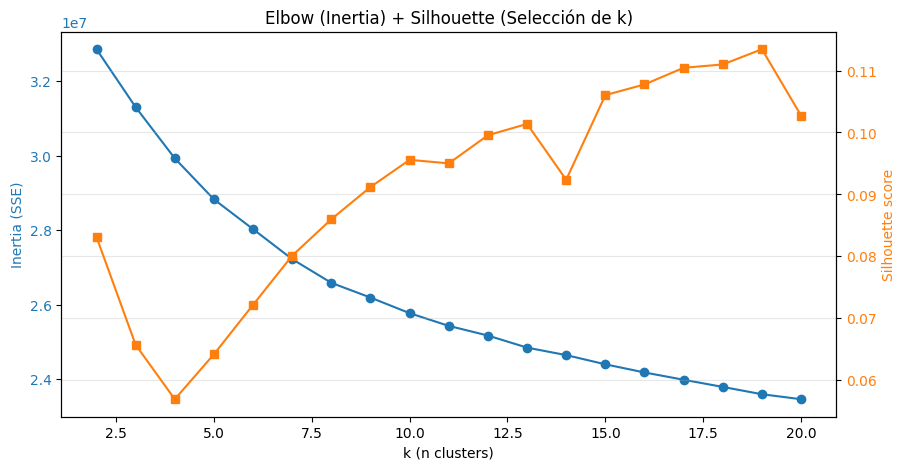

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# --- VARIABLES BASE ---
X = embeddings            # embeddings originales (alta dimensión)
X_umap = embeddings_reduced  # embeddings reducidos a 2D con UMAP


# --- OPCIONAL: escalar los embeddings antes del clustering ---
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(X)

# --- BÚSQUEDA DEL NÚMERO ÓPTIMO DE CLUSTERS ---
ks = list(range(2, 21))
inertias = []
sil_scores = []
sample_for_silhouette = 10000  # usa una muestra para acelerar el cálculo

n_samples = X.shape[0]
rng = np.random.RandomState(42)
sil_sample_idx = rng.choice(n_samples, min(sample_for_silhouette, n_samples), replace=False)

for k in ks:
    print(f"Computing KMeans k={k} ...", end=" ")
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)
    
    # silhouette sobre una muestra
    labels_sample = km.labels_[sil_sample_idx]
    X_sample = X[sil_sample_idx]
    sil = silhouette_score(X_sample, labels_sample)
    sil_scores.append(sil)
    
    print(f"done (inertia={km.inertia_:.1f}, silhouette={sil:.4f})")

# --- PLOT ELBOW Y SILHOUETTE ---
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(ks, inertias, '-o', color='tab:blue')
ax1.set_xlabel("k (n clusters)")
ax1.set_ylabel("Inertia (SSE)", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(ks, sil_scores, '-s', color='tab:orange')
ax2.set_ylabel("Silhouette score", color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title("Elbow (Inertia) + Silhouette (Selección de k)")
plt.grid(alpha=0.3)
plt.show()


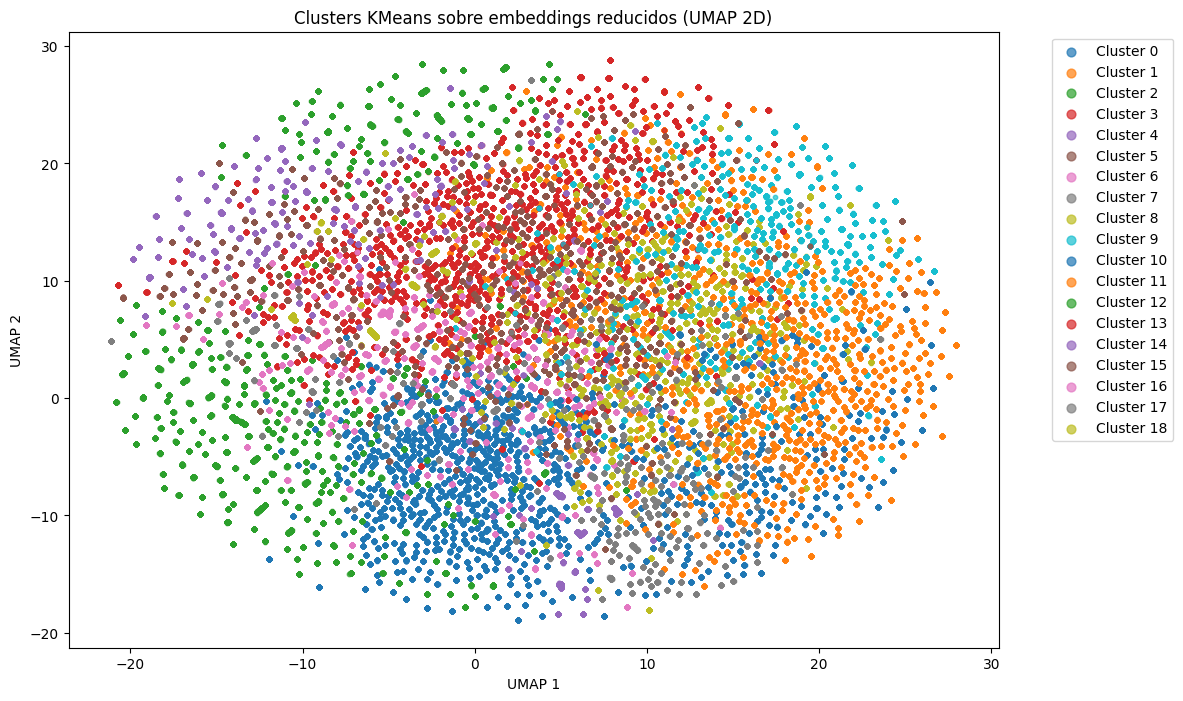

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# --- ELEGIR k FINAL Y CLUSTERIZAR ---
n_clusters = 19  # (ajustá según lo que veas en el gráfico anterior)
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit(X)
labels = kmeans.labels_

# --- GRAFICAR EN EL ESPACIO UMAP ---
palette = sns.color_palette("tab10", n_clusters)

plt.figure(figsize=(12, 8))
for c in range(n_clusters):
    mask = labels == c
    plt.scatter(X_umap[mask, 0], X_umap[mask, 1], 
                s=10, c=[palette[c]], label=f"Cluster {c}", alpha=0.7)

plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1))
plt.title("Clusters KMeans sobre embeddings reducidos (UMAP 2D)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()